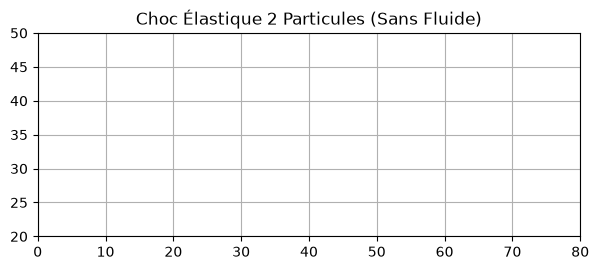

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numba as nb

@nb.jit(nopython=True, fastmath=True)
def resolve_particle_collisions(marker_pos, marker_vel, D_particle):
    R = D_particle / 2.0
    min_dist_sq = (2.0 * R) ** 2
    
    rx = marker_pos[0, 0] - marker_pos[1, 0]
    ry = marker_pos[0, 1] - marker_pos[1, 1]
    rz = marker_pos[0, 2] - marker_pos[1, 2]
    
    vx = marker_vel[0, 0] - marker_vel[1, 0]
    vy = marker_vel[0, 1] - marker_vel[1, 1]
    vz = marker_vel[0, 2] - marker_vel[1, 2]
    
    dist_sq = rx**2 + ry**2 + rz**2
    a = vx**2 + vy**2 + vz**2
    b = 2.0 * (rx*vx + ry*vy + rz*vz)
    c = dist_sq - min_dist_sq

    if a > 0.0 and b < 0.0 and (b**2 - 4.0*a*c) >= 0.0:
        delta_t = (-b - np.sqrt(b**2 - 4.0*a*c)) / (2.0 * a)
        
        if 0.0 <= delta_t <= 1.0:
            rx_impact = rx + vx * delta_t
            ry_impact = ry + vy * delta_t
            rz_impact = rz + vz * delta_t
            dist_impact = np.sqrt(rx_impact**2 + ry_impact**2 + rz_impact**2)
            
            if dist_impact > 0.0:
                nx, ny, nz = rx_impact / dist_impact, ry_impact / dist_impact, rz_impact / dist_impact
                v_dot_n = vx * nx + vy * ny + vz * nz
                
                v0_x, v0_y, v0_z = marker_vel[0, 0], marker_vel[0, 1], marker_vel[0, 2]
                v1_x, v1_y, v1_z = marker_vel[1, 0], marker_vel[1, 1], marker_vel[1, 2]
                
                marker_vel[0, 0] -= v_dot_n * nx
                marker_vel[0, 1] -= v_dot_n * ny
                marker_vel[0, 2] -= v_dot_n * nz
                
                marker_vel[1, 0] += v_dot_n * nx
                marker_vel[1, 1] += v_dot_n * ny
                marker_vel[1, 2] += v_dot_n * nz

                marker_pos[0, 0] += v0_x * delta_t + marker_vel[0, 0] * (1.0 - delta_t)
                marker_pos[0, 1] += v0_y * delta_t + marker_vel[0, 1] * (1.0 - delta_t)
                marker_pos[0, 2] += v0_z * delta_t + marker_vel[0, 2] * (1.0 - delta_t)
                
                marker_pos[1, 0] += v1_x * delta_t + marker_vel[1, 0] * (1.0 - delta_t)
                marker_pos[1, 1] += v1_y * delta_t + marker_vel[1, 1] * (1.0 - delta_t)
                marker_pos[1, 2] += v1_z * delta_t + marker_vel[1, 2] * (1.0 - delta_t)
                return

    marker_pos[0, :] += marker_vel[0, :]
    marker_pos[1, :] += marker_vel[1, :]

# Simulation parameters
Nt = 120
D_particle = 6.0
R = D_particle / 2.0

marker_pos = np.array([[10.0, 40.0, 35.0], [50.0, 35.0, 35.0]], dtype=np.float64)
marker_vel = np.array([[0.8, 0.0, 0.0], [0.0, 0.0, 0.0]], dtype=np.float64)

# Figure 
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim(0, 80)
ax.set_ylim(20, 50)
ax.set_aspect('equal')
ax.set_title("Choc Élastique 2 Particules (Sans Fluide)")
ax.grid(True)

c1 = plt.Circle((marker_pos[0, 0], marker_pos[0, 1]), R, color='blue', fill=True, alpha=0.6)
c2 = plt.Circle((marker_pos[1, 0], marker_pos[1, 1]), R, color='red', fill=True, alpha=0.6)
ax.add_patch(c1)
ax.add_patch(c2)

def update(frame):
    resolve_particle_collisions(marker_pos, marker_vel, D_particle)
    c1.set_center((marker_pos[0, 0], marker_pos[0, 1]))
    c2.set_center((marker_pos[1, 0], marker_pos[1, 1]))
    return c1, c2

# GIF creation
ani = animation.FuncAnimation(fig, update, frames=Nt, interval=30, blit=True)

# Save GIF
ani.save('collision.gif', writer='pillow', fps=30)

plt.show()